# AED praca domowa 1: Eksploracja reguł asocjacyjnych
## Zakres analizy
**Cel:** Identyfikacja popularnych produktów, wyznaczenie reguł asocjacyjnych oraz porównanie nawyków zakupowych klientów z Polski i Niemiec. Wybrałem naszych zachodnich sąsiadów, ponieważ po UK, którego nie mogłem użyć, jest to najliczniejszy pod względem transakcji kraj.

Notebook zawiera następujące kroki:
* Wczytanie i wstępne sprawdzenie danych;
* Czyszczenie danych;
* Agregacja produktów według numeru faktury `InvoiceNo`;
* Analiza pod kątem liczby transakcji, produktów i krajów;
* Identyfikacja popularnych produktów;
* Wyszukiwanie częstych zbiorów produktów metodą FP-Growth;
* Wyznaczenie reguł asocjacyjnych z użyciem miar: confidence, lift, conviction i Laplace;
* Porównanie wyników dla Polski i Niemiec;
* Podsumowanie wyników i ograniczeń analizy.

Wykorzystane biblioteki:


* pandas: 3.0.2
* numpy: 2.4.4
* matplotlib: 3.10.9
* mlxtend: 0.24.0
* openpyxl: 3.1.5

## 1. Wczytanie i wstępne sprawdzenie danych


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# fix do transformacji excela
from pathlib import Path

# ze względu na pakiety Colab'a wyłączam powiadomienia, które pokazywały się przy algorytmie FP-Growth
import warnings
warnings.filterwarnings("ignore")

# ustawiam ograniczenia ze względu na duży dataset
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

# dla czytelności i łatwości pracy, bo miałem na początku parę problemów z pracą w Colab
FILE_PATH = "data/Transactions_full.xlsx"
SHEET_NAME = "Online Retail"

# consty z krajami do analizy
COUNTRY_BASE = "Poland"
COUNTRY_TO_COMPARE = "Germany"


# OUTPUT_DIR = "/content/aed_outputs"
# os.makedirs(OUTPUT_DIR, exist_ok=True)


# ustawiam reguły tutaj, dla poprawy czytelności
MIN_SUPPORT_GLOBAL = 0.02
MIN_CONFIDENCE_GLOBAL = 0.5

MIN_SUPPORT_COUNTRY = 0.03
MIN_CONFIDENCE_COUNTRY = 0.5

print("Oczekwiany filepath dla zbioru danych:", FILE_PATH)
# print("Dane wyjściowe znajdują się w:", OUTPUT_DIR)

Oczekwiany filepath dla zbioru danych: data/Transactions_full.xlsx


## 2. Wczytanie pliku i sprawdzenie arkusza

Robię to, ponieważ miałem problem z tymczasowym wczytywaniem pliku excelowego

In [23]:
if not Path(FILE_PATH).exists():
    raise FileNotFoundError(
        f"Nie znaleziono pliku: {FILE_PATH}. "
        "Sprawdź ścieżkę lub wczytaj plik Transactions_full.xlsx ponownie."
    )

excel_file = pd.ExcelFile(FILE_PATH)
print("Dostępne arkusze:")
print(excel_file.sheet_names)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

PICKLE_PATH = DATA_DIR / "transactions_full.pkl"

if PICKLE_PATH.exists():
    df_raw = pd.read_pickle(PICKLE_PATH)
    print("\nWczytano dane z pamięci podręcznej Pickle.")
else:
    df_raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
    df_raw.to_pickle(PICKLE_PATH)
    print("\nWczytano dane z Excela i zapisano kopię Pickle.")

print("\nWczytano arkusz:", SHEET_NAME)
print("Kształt danych:", df_raw.shape)

display(df_raw.head())

Dostępne arkusze:
['Online Retail', 'Sheet1']

Wczytano dane z pamięci podręcznej Pickle.

Wczytano arkusz: Online Retail
Kształt danych: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Wstępna analiza i czyszczenie danych

W tej sekcji sprawdzę strukturę danych oraz wykonuję podstawowe czyszczenie: anulowane faktury, puste wiersze bez kluczowych wartości albo złym formatem ilości/danych. Dzięki temu analiza bedzie na poprawnych danych

In [24]:
print("Kolumny:")
print(df_raw.columns.tolist())

print("\nBrakujące wartosic:")
display(df_raw.isna().sum())

print("\nInfo podstawowe:")
display(df_raw.head())

df = df_raw.copy()

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["Description"] = df["Description"].astype(str).str.strip()
df["Country"] = df["Country"].astype(str).str.strip()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

rows_before = len(df)

df = df.dropna(subset=["InvoiceNo", "Description", "Country", "InvoiceDate"])
df = df[
    (df["Description"].str.lower() != "nan") &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (~df["InvoiceNo"].str.startswith("C"))
].copy()

rows_after = len(df)

print("Wierszy przed czyszczenie:", rows_before)
print("Ilość wierszy po czyszczeniu:", rows_after)
print("Usunięto:", rows_before - rows_after)

display(df.head())

Kolumny:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Brakujące wartosic:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Info podstawowe:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Wierszy przed czyszczenie: 541909
Ilość wierszy po czyszczeniu: 530104
Usunięto: 11805


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 4. Agregajca produktów wg numeru faktury

Zgodnie z wymaganiami, produkty agreguję wg `INvoiceNo`.
Każda faka jest traktoowana jako jeden koszyk transakcji. Powtarzające się produkty są liczone jednokrotnie, ponieważ przy analizie asocjacyjnej ważna jest obecność produktu w koszyku, a nie ilosć sztuk.

In [25]:
basket_df = (
    df.groupby("InvoiceNo")
    .agg(
        Products=("Description", lambda x: sorted(set(x))),
        ProductString=("Description", lambda x: ", ".join(sorted(set(x)))),
        Country=("Country", lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
        InvoiceDate=("InvoiceDate", "min"),
        ProductCount=("Description", "nunique")
    )
    .reset_index()
)

print("Ilość zagergowanych transakcji: ", basket_df["InvoiceNo"].nunique())
display(basket_df.head()
)

Ilość zagergowanych transakcji:  19960


,InvoiceNo,Products,ProductString,Country,InvoiceDate,ProductCount
0,536365,"[CREAM CUPID HEARTS COAT HANGER, GLASS STAR FROSTED T-LIGHT HOLDER, KNITTED UNION FLAG HOT WATER BOTTLE, RED WOOLLY ...","CREAM CUPID HEARTS COAT HANGER, GLASS STAR FROSTED T-LIGHT HOLDER, KNITTED UNION FLAG HOT WATER BOTTLE, RED WOOLLY H...",United Kingdom,2010-12-01 08:26:00,7
1,536366,"[HAND WARMER RED POLKA DOT, HAND WARMER UNION JACK]","HAND WARMER RED POLKA DOT, HAND WARMER UNION JACK",United Kingdom,2010-12-01 08:28:00,2
2,536367,"[ASSORTED COLOUR BIRD ORNAMENT, BOX OF 6 ASSORTED COLOUR TEASPOONS, BOX OF VINTAGE ALPHABET BLOCKS, BOX OF VINTAGE J...","ASSORTED COLOUR BIRD ORNAMENT, BOX OF 6 ASSORTED COLOUR TEASPOONS, BOX OF VINTAGE ALPHABET BLOCKS, BOX OF VINTAGE JI...",United Kingdom,2010-12-01 08:34:00,12
3,536368,"[BLUE COAT RACK PARIS FASHION, JAM MAKING SET WITH JARS, RED COAT RACK PARIS FASHION, YELLOW COAT RACK PARIS FASHION]","BLUE COAT RACK PARIS FASHION, JAM MAKING SET WITH JARS, RED COAT RACK PARIS FASHION, YELLOW COAT RACK PARIS FASHION",United Kingdom,2010-12-01 08:34:00,4
4,536369,[BATH BUILDING BLOCK WORD],BATH BUILDING BLOCK WORD,United Kingdom,2010-12-01 08:35:00,1


## 5. Charakterystyka zbioru danych
Czyli okres zebranych danych, liczba transakcji i unikatowych produktów. Dodatkowo rozkład liczby transakcji wg karjów.

In [26]:
date_min = df["InvoiceDate"].min()
date_max = df["InvoiceDate"].max()

n_transactions = basket_df["InvoiceNo"].nunique()
n_unique_products = df["Description"].nunique()
n_countries = df["Country"].nunique()

summary_table = pd.DataFrame({
    "Metric": [
        "Początek okresu danych:",
        "Koniec okresu danych:",
        "Liczba transakcji:",
        "Liczba unikatowych produktów:",
        "Liczba krajów:"
    ],
    "Value": [
        date_min,
        date_max,
        n_transactions,
        n_unique_products,
        n_countries
    ]
})

country_transactions = (
    basket_df["Country"]
    .value_counts()
    .rename_axis("Country")
    .reset_index(name="Ilość transakcji")
)

country_transactions["Procent składowy"] = (
    country_transactions["Ilość transakcji"] / country_transactions["Ilość transakcji"].sum() * 100
).round(2)

display(summary_table)
display(country_transactions)

,Metric,Value
0,Początek okresu danych:,2010-12-01 08:26:00
1,Koniec okresu danych:,2011-12-09 12:50:00
2,Liczba transakcji:,19960
3,Liczba unikatowych produktów:,4015
4,Liczba krajów:,38


,Country,Ilość transakcji,Procent składowy
0,United Kingdom,18019,90.28
1,Germany,457,2.29
2,France,392,1.96
3,EIRE,288,1.44
4,Belgium,98,0.49
5,Netherlands,94,0.47
6,Spain,90,0.45
7,Portugal,58,0.29
8,Australia,57,0.29
9,Switzerland,54,0.27


## 6. Liczba transakcji wg krajów

Poniższe wykresy przedstawią liczbę transakcji dla poszczególnych krajów, z niezdrową przewagą dla UK. Dlatego wybrałem top 15, wyłączając UK. Drugi wykres przedstawia wizualnie porównanie ilości transakcji wraz z UK. Sortowane malejąco :D

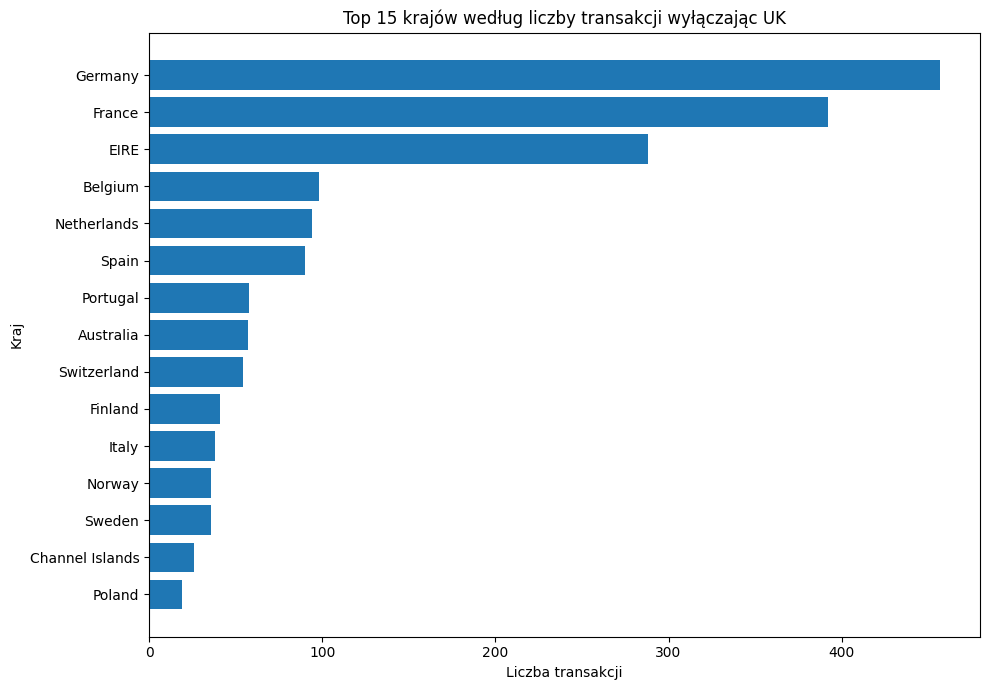

,Country,Ilość transakcji,Procent składowy
1,Germany,457,2.29
2,France,392,1.96
3,EIRE,288,1.44
4,Belgium,98,0.49
5,Netherlands,94,0.47
6,Spain,90,0.45
7,Portugal,58,0.29
8,Australia,57,0.29
9,Switzerland,54,0.27
10,Finland,41,0.21


In [27]:
country_transactions_no_uk = country_transactions[
    country_transactions["Country"] != "United Kingdom"
].copy()

top_n = 15
country_plot = country_transactions_no_uk.head(top_n).sort_values(
    "Ilość transakcji",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(country_plot["Country"], country_plot["Ilość transakcji"])
plt.title(f"Top {top_n} krajów według liczby transakcji wyłączając UK")
plt.xlabel("Liczba transakcji")
plt.ylabel("Kraj")
plt.tight_layout()
plt.show()

display(country_transactions_no_uk)

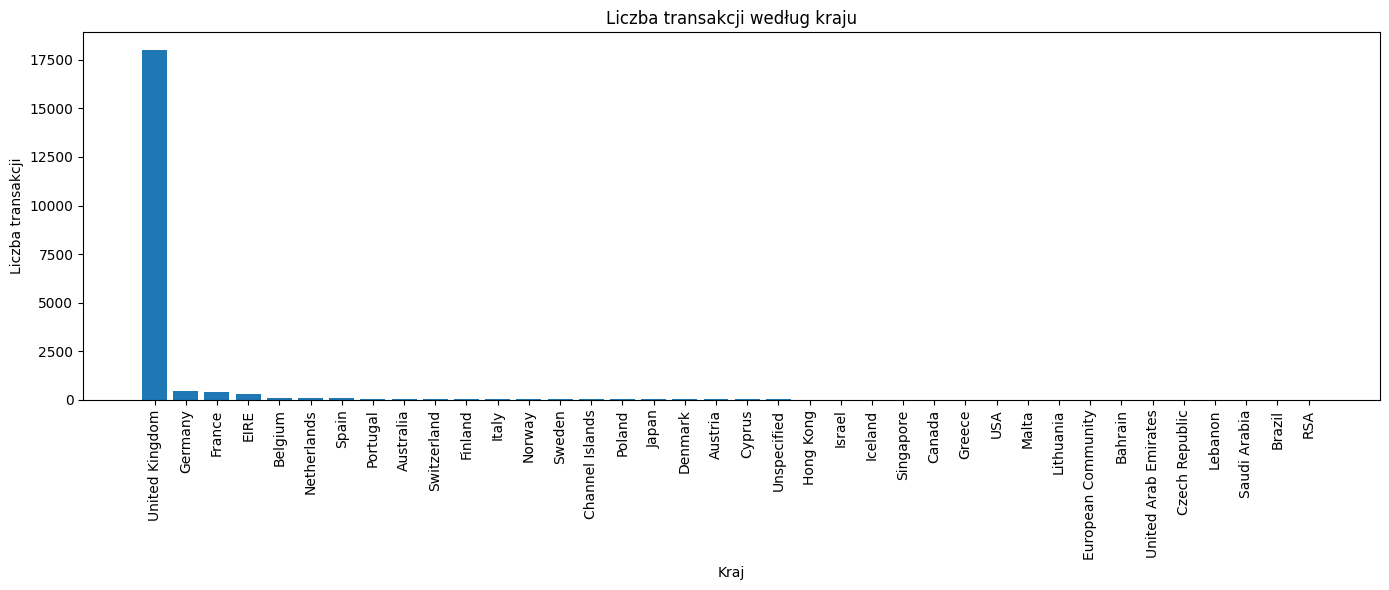

In [28]:
plt.figure(figsize=(14, 6))
plt.bar(country_transactions["Country"], country_transactions["Ilość transakcji"])
plt.xticks(rotation=90)
plt.title("Liczba transakcji według kraju")
plt.xlabel("Kraj")
plt.ylabel("Liczba transakcji")
plt.tight_layout()
plt.show()

## 7. Binary encoding transkacji

Aby działać poprawnie, algorytm FPGrowth wymaga danych binarnych, gdzie każdy wiersz oznacza jedną transsakcję, a każda kolumna jeden produkt. Wartość `True` oznacza wystąpienie produktu w transakcji.

In [ ]:
def encode_transactions(transactions):
    encoder = TransactionEncoder()
    encoded_array = encoder.fit(transactions).transform(transactions)
    onehot_df = pd.DataFrame(encoded_array, columns=encoder.columns_)
    return onehot_df

transactions_global = basket_df["Products"].tolist()
onehot_global = encode_transactions(transactions_global)

print("Kształt macierzy dla transakcji binarnych:", onehot_global.shape)
display(onehot_global.head())

Kształt macierzy dla transakcji binarnych: (19960, 4015)


,*Boombox Ipod Classic,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 8. Produkty popularne i rzadkie

Wyznaczenie wyników na podstawie odsetka transkacji

In [30]:
product_support = (
    onehot_global.mean()
    .sort_values(ascending=False)
    .reset_index()
)

product_support.columns = ["Product", "Support"]

top_10_products = product_support.head(10)
rare_10_products = product_support.tail(10).sort_values("Support", ascending=True)

print("Top 10 najczęstszych produktów:")
display(top_10_products)

print("Top 10 najrzadszych produktów:")
display(rare_10_products)

Top 10 najczęstszych produktów:


,Product,Support
0,WHITE HANGING HEART T-LIGHT HOLDER,0.113026
1,JUMBO BAG RED RETROSPOT,0.104659
2,REGENCY CAKESTAND 3 TIER,0.099599
3,PARTY BUNTING,0.084419
4,LUNCH BAG RED RETROSPOT,0.078357
5,ASSORTED COLOUR BIRD ORNAMENT,0.072896
6,SET OF 3 CAKE TINS PANTRY DESIGN,0.069389
7,PACK OF 72 RETROSPOT CAKE CASES,0.066132
8,LUNCH BAG BLACK SKULL.,0.063778
9,NATURAL SLATE HEART CHALKBOARD,0.062575


Top 10 najrzadszych produktów:


,Product,Support
4005,IVORY PANTRY HANGING LAMP,0.00005
4006,WRAP PINK FLOCK,0.00005
4007,PINK POLKADOT KIDS BAG,0.00005
4008,ZINC STAR T-LIGHT HOLDER,0.00005
4009,*Boombox Ipod Classic,0.00005
4010,SET 10 CARDS 12 DAYS OF XMAS 17059,0.00005
4011,SET 10 CARDS 3 WISE MEN 17107,0.00005
4012,SET 10 CARDS CHRISTMAS BAUBLE 16954,0.00005
4013,ZINC PLANT POT HOLDER,0.00005
4014,16 PC CUTLERY SET PANTRY DESIGN,0.00005


# 9. Wizualizacja popularnych i rzadkich przedmiotów

Poniższe wykresy pokazują produkty cieszące się popularnością (i nie) w zbiorze danych.

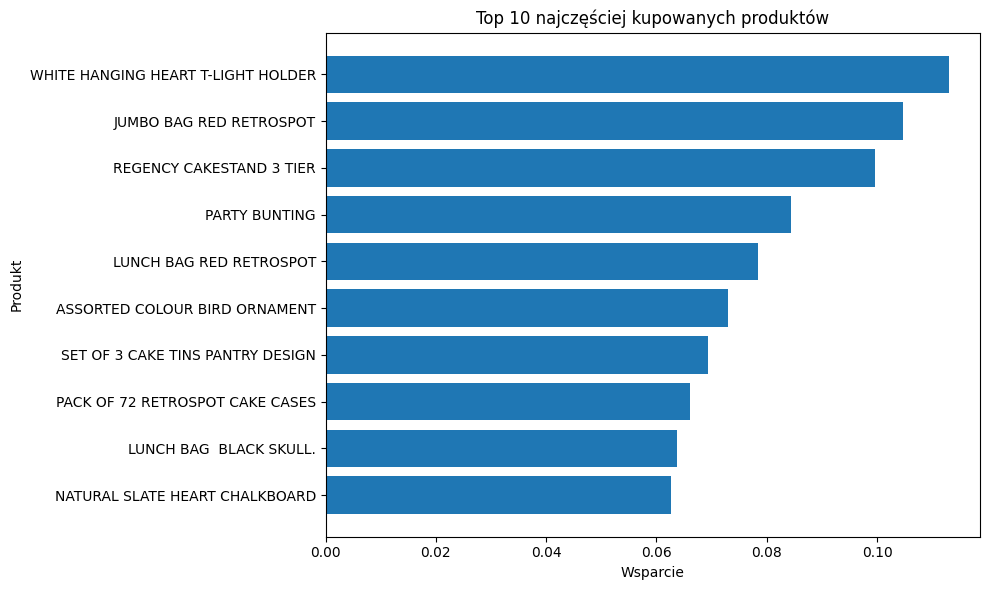

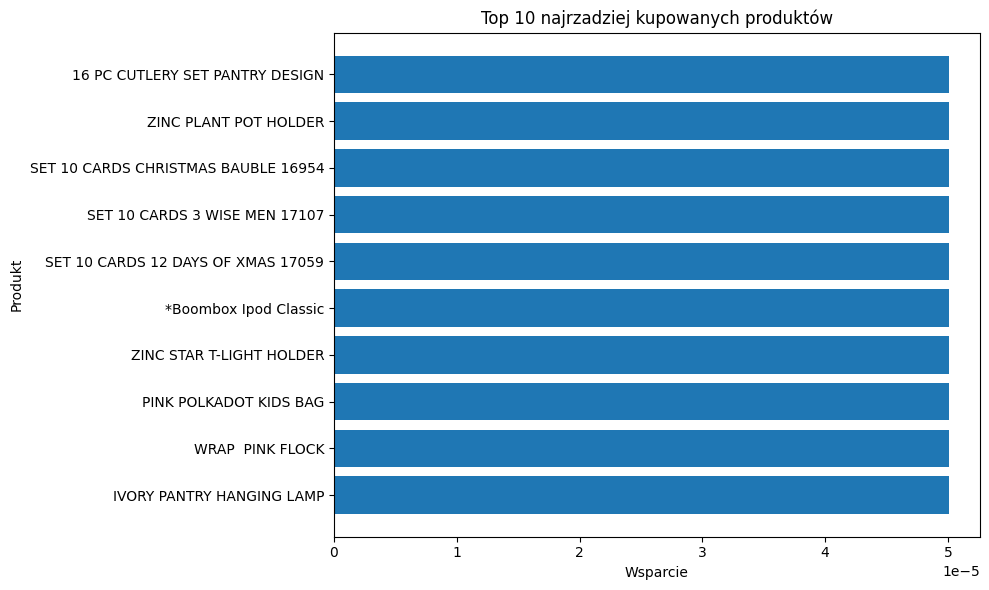

In [31]:
def plot_support_bar(data, title):
    plot_data = data.sort_values("Support", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_data["Product"], plot_data["Support"])
    plt.title(title)
    plt.xlabel("Wsparcie")
    plt.ylabel("Produkt")
    plt.tight_layout()
    plt.show()

plot_support_bar(top_10_products, "Top 10 najczęściej kupowanych produktów")
plot_support_bar(rare_10_products, "Top 10 najrzadziej kupowanych produktów")

## 10. Wyszukiwanie metodą FP-Growth

Usecase algorytmu znalezienia częstych zbiorów produktów. Minimalne wsparcie ustawione na poziomie 0.02, czyli dany zbiór musi występować w conajmniej 2% transackji.

In [32]:
frequent_itemsets_global = fpgrowth(
    onehot_global,
    min_support=MIN_SUPPORT_GLOBAL,
    use_colnames=True
)

frequent_itemsets_global["Length"] = frequent_itemsets_global["itemsets"].apply(len)
frequent_itemsets_global["Itemsets"] = frequent_itemsets_global["itemsets"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

frequent_itemsets_global = frequent_itemsets_global.sort_values(
    ["support", "Length"],
    ascending=[False, True]
).reset_index(drop=True)

print("Number of frequent itemsets:", len(frequent_itemsets_global))
display(frequent_itemsets_global[["Itemsets", "support", "Length"]].head(20))

Number of frequent itemsets: 379


,Itemsets,support,Length
0,WHITE HANGING HEART T-LIGHT HOLDER,0.113026,1
1,JUMBO BAG RED RETROSPOT,0.104659,1
2,REGENCY CAKESTAND 3 TIER,0.099599,1
3,PARTY BUNTING,0.084419,1
4,LUNCH BAG RED RETROSPOT,0.078357,1
5,ASSORTED COLOUR BIRD ORNAMENT,0.072896,1
6,SET OF 3 CAKE TINS PANTRY DESIGN,0.069389,1
7,PACK OF 72 RETROSPOT CAKE CASES,0.066132,1
8,LUNCH BAG BLACK SKULL.,0.063778,1
9,NATURAL SLATE HEART CHALKBOARD,0.062575,1


## 11. Reguyły asocjacyjne dla całego zbioru

Minimalny `confidence` ustawiony na poziomie 0.5, czyli konsekwent reguły musi występować w conajmniej 50% transakcji zawierajacych poprzednik reguły.

Dodatkowo obliczam miarę Laplace, ponieważ nie jest domyślnie zwracana przez funkcję `association_rules`.

In [33]:
rules_global = association_rules(
    frequent_itemsets_global,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE_GLOBAL
)

rules_global["Antecedents"] = rules_global["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

rules_global["Consequents"] = rules_global["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

rules_global["Laplace"] = (
    rules_global["support"] * n_transactions + 1
) / (
    rules_global["antecedent support"] * n_transactions + 2
)

rules_global_clean = rules_global[
    [
        "Antecedents",
        "Consequents",
        "antecedent support",
        "consequent support",
        "support",
        "confidence",
        "lift",
        "conviction",
        "Laplace"
    ]
].copy()

print("Number of generated rules:", len(rules_global_clean))
display(rules_global_clean.head(10))

Number of generated rules: 61


,Antecedents,Consequents,antecedent support,consequent support,support,confidence,lift,conviction,Laplace
0,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,0.061022,0.104659,0.041333,0.677340,6.471855,2.774873,0.677049
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.050752,0.053357,0.038427,0.757157,14.190472,3.898169,0.756650
2,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.053357,0.050752,0.038427,0.720188,14.190472,3.392448,0.719775
3,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,0.059319,0.104659,0.036273,0.611486,5.842638,2.304529,0.611298
4,JUMBO SHOPPER VINTAGE RED PAISLEY,JUMBO BAG RED RETROSPOT,0.058868,0.104659,0.034068,0.578723,5.529593,2.125304,0.578590
5,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,0.063778,0.078357,0.032114,0.503535,6.426188,1.856411,0.503529
6,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.049098,0.052655,0.032064,0.653061,12.402571,2.730582,0.652749
7,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.052655,0.049098,0.032064,0.608944,12.402571,2.431625,0.608737
8,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.050752,0.038327,0.031663,0.623889,16.278213,2.556890,0.623645
9,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.038327,0.050752,0.031663,0.826144,16.278213,5.459963,0.825293


## 12. Najlepsze reguły wg wybranych miar jakości

Tu przedstawiam 10 najlepszych reguł asocjacyjnych wg czterech, wymagancyh w zadaniu miar, tj. `confidence`, `lift`, `conviction` oraz `Laplace`.

In [34]:
def top_rules_by_metric(rules_df, metric, n=10):
    result = (
        rules_df
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[metric])
        .sort_values(metric, ascending=False)
        .head(n)
        .reset_index(drop=True)
    )
    return result

top_rules_confidence = top_rules_by_metric(rules_global_clean, "confidence", 10)
top_rules_lift = top_rules_by_metric(rules_global_clean, "lift", 10)
top_rules_conviction = top_rules_by_metric(rules_global_clean, "conviction", 10)
top_rules_laplace = top_rules_by_metric(rules_global_clean, "Laplace", 10)

print("Top 10 reguł według confidence")
display(top_rules_confidence)

print("\nTop 10 reguł według lift")
display(top_rules_lift)

print("\nTop 10 reguł według conviction")
display(top_rules_conviction)

print("\nTop 10 reguł według Laplace")
display(top_rules_laplace)

Top 10 reguł według confidence


,Antecedents,Consequents,antecedent support,consequent support,support,confidence,lift,conviction,Laplace
0,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.029960,0.050752,0.027104,0.904682,17.825724,9.958782,0.903333
1,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",ROSES REGENCY TEACUP AND SAUCER,0.031663,0.053357,0.027104,0.856013,16.043204,6.574490,0.854890
2,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.038327,0.050752,0.031663,0.826144,16.278213,5.459963,0.825293
3,"JUMBO BAG PINK POLKADOT, JUMBO STORAGE BAG SUKI",JUMBO BAG RED RETROSPOT,0.025802,0.104659,0.020691,0.801942,7.662402,4.520593,0.800774
4,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER",ROSES REGENCY TEACUP AND SAUCER,0.025501,0.053357,0.020441,0.801572,15.022884,4.770707,0.800391
5,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.038327,0.053357,0.029960,0.781699,14.650440,4.336420,0.780965
6,"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.026303,0.050752,0.020441,0.777143,15.312706,4.259448,0.776091
7,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.050752,0.053357,0.038427,0.757157,14.190472,3.898169,0.756650
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.037976,0.045741,0.027355,0.720317,15.747557,3.411924,0.719737
9,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.053357,0.050752,0.038427,0.720188,14.190472,3.392448,0.719775



Top 10 reguł według lift


,Antecedents,Consequents,antecedent support,consequent support,support,confidence,lift,conviction,Laplace
0,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",0.038327,0.038427,0.027104,0.707190,18.403524,3.283944,0.706649
1,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",PINK REGENCY TEACUP AND SAUCER,0.038427,0.038327,0.027104,0.705346,18.403524,3.263732,0.704811
2,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.029960,0.050752,0.027104,0.904682,17.825724,9.958782,0.903333
3,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",0.050752,0.029960,0.027104,0.534057,17.825724,2.081887,0.533990
4,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.038327,0.050752,0.031663,0.826144,16.278213,5.459963,0.825293
5,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.050752,0.038327,0.031663,0.623889,16.278213,2.556890,0.623645
6,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",0.053357,0.031663,0.027104,0.507981,16.043204,1.968089,0.507966
7,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",ROSES REGENCY TEACUP AND SAUCER,0.031663,0.053357,0.027104,0.856013,16.043204,6.574490,0.854890
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.037976,0.045741,0.027355,0.720317,15.747557,3.411924,0.719737
9,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.045741,0.037976,0.027355,0.598028,15.747557,2.393264,0.597814



Top 10 reguł według conviction


,Antecedents,Consequents,antecedent support,consequent support,support,confidence,lift,conviction,Laplace
0,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.029960,0.050752,0.027104,0.904682,17.825724,9.958782,0.903333
1,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",ROSES REGENCY TEACUP AND SAUCER,0.031663,0.053357,0.027104,0.856013,16.043204,6.574490,0.854890
2,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.038327,0.050752,0.031663,0.826144,16.278213,5.459963,0.825293
3,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER",ROSES REGENCY TEACUP AND SAUCER,0.025501,0.053357,0.020441,0.801572,15.022884,4.770707,0.800391
4,"JUMBO BAG PINK POLKADOT, JUMBO STORAGE BAG SUKI",JUMBO BAG RED RETROSPOT,0.025802,0.104659,0.020691,0.801942,7.662402,4.520593,0.800774
5,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.038327,0.053357,0.029960,0.781699,14.650440,4.336420,0.780965
6,"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.026303,0.050752,0.020441,0.777143,15.312706,4.259448,0.776091
7,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.050752,0.053357,0.038427,0.757157,14.190472,3.898169,0.756650
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.037976,0.045741,0.027355,0.720317,15.747557,3.411924,0.719737
9,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.053357,0.050752,0.038427,0.720188,14.190472,3.392448,0.719775



Top 10 reguł według Laplace


,Antecedents,Consequents,antecedent support,consequent support,support,confidence,lift,conviction,Laplace
0,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.029960,0.050752,0.027104,0.904682,17.825724,9.958782,0.903333
1,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",ROSES REGENCY TEACUP AND SAUCER,0.031663,0.053357,0.027104,0.856013,16.043204,6.574490,0.854890
2,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.038327,0.050752,0.031663,0.826144,16.278213,5.459963,0.825293
3,"JUMBO BAG PINK POLKADOT, JUMBO STORAGE BAG SUKI",JUMBO BAG RED RETROSPOT,0.025802,0.104659,0.020691,0.801942,7.662402,4.520593,0.800774
4,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER",ROSES REGENCY TEACUP AND SAUCER,0.025501,0.053357,0.020441,0.801572,15.022884,4.770707,0.800391
5,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.038327,0.053357,0.029960,0.781699,14.650440,4.336420,0.780965
6,"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.026303,0.050752,0.020441,0.777143,15.312706,4.259448,0.776091
7,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.050752,0.053357,0.038427,0.757157,14.190472,3.898169,0.756650
8,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.053357,0.050752,0.038427,0.720188,14.190472,3.392448,0.719775
9,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.037976,0.045741,0.027355,0.720317,15.747557,3.411924,0.719737


## 14. Analiza asocjacyjna dla kraju

W tej sekcji tworzę funkcję wykonującą analizę koszykową dla wybranego kraju.
Funkcja zwraca najpopularniejsze produkty, pary i trójki + reguły asocjacyjne godne uwagi. "Przyznaję bez bicia", że dla ułatwienia pracy wspierałem się już tutaj Codex'em.

In [ ]:
from collections import Counter
import time

def analyze_country_fast(
    country,
    min_support=0.03,
    min_confidence=0.5,
    top_k_products=80,
    max_basket_size=40
):
    start = time.time()

    # Cache dla koszyków poszczególnych krajów
    country_baskets = basket_df[basket_df["Country"] == country].copy()

    print("=" * 90)
    print("Kraj:", country)
    print("Ilość transakcji przed zmianami:", len(country_baskets))

    # Obsługa wydarzenia pustego koszyka
    if len(country_baskets) == 0:
        print("Nie znaleziono transkacji.")
        return None

    # Redukcja pod kątem małych albo bardzo dużych koszyków
    country_baskets = country_baskets[
        (country_baskets["ProductCount"] >= 2) &
        (country_baskets["ProductCount"] <= max_basket_size)
    ].copy()

    print("Transakcji po filtrowaniu wielkości koszyka:", len(country_baskets))

    # Zliczanie produktów przy użyciu Counter() dla produktów wyłącznie z danego kraju
    product_counter = Counter()
    for products in country_baskets["Products"]:
        product_counter.update(products)

    # Zachowaj tylko najczęstsze wyniki dla k przedmiotów
    allowed_products = {
        product
        for product, count in product_counter.most_common(top_k_products)
    }

    country_baskets["Products_Country_Filtered"] = country_baskets["Products"].apply(
        lambda products: [p for p in products if p in allowed_products]
    )

    country_baskets = country_baskets[
        country_baskets["Products_Country_Filtered"].apply(len) >= 2
    ].copy()

    transactions = country_baskets["Products_Country_Filtered"].tolist()

    print("Transakcji po filtrowaniu produktów:", len(country_baskets))
    print("Dozwolonych produktów:", len(allowed_products))

    if len(transactions) == 0:
        print("Brak transakcji po filtrowaniu...")
        return None

    onehot = encode_transactions(transactions)

    print("One-hot matrix shape:", onehot.shape)

    # Wsparcie dla produktu
    product_support = (
        onehot.mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    product_support.columns = ["Product", "Support"]
    top_products = product_support.head(5)

    # FP-Growth dla zestawów przedmiotów
    frequent_itemsets = fpgrowth(
        onehot,
        min_support=min_support,
        use_colnames=True,
        max_len=3
    )

    if frequent_itemsets.empty:
        print("Brak często powtarzanych zestawów. Spróbuj obniżyć min_support.")
        return {
            "country": country,
            "transactions": len(country_baskets),
            "top_products": top_products,
            "top_pairs": pd.DataFrame(),
            "top_triples": pd.DataFrame(),
            "rules": pd.DataFrame()
        }

    frequent_itemsets["Length"] = frequent_itemsets["itemsets"].apply(len)
    frequent_itemsets["Itemsets"] = frequent_itemsets["itemsets"].apply(
        lambda x: ", ".join(sorted(list(x)))
    )

    top_pairs = (
        frequent_itemsets[frequent_itemsets["Length"] == 2]
        .sort_values("support", ascending=False)
        .head(5)
        [["Itemsets", "support"]]
        .reset_index(drop=True)
    )

    top_triples = (
        frequent_itemsets[frequent_itemsets["Length"] == 3]
        .sort_values("support", ascending=False)
        .head(5)
        [["Itemsets", "support"]]
        .reset_index(drop=True)
    )

    # Określenie reguł asocjacyjnych
    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=min_confidence
    )

    if rules.empty:
        rules_clean = pd.DataFrame()
    else:
        rules["Antecedents"] = rules["antecedents"].apply(
            lambda x: ", ".join(sorted(list(x)))
        )
        rules["Consequents"] = rules["consequents"].apply(
            lambda x: ", ".join(sorted(list(x)))
        )

        n_country_transactions = len(country_baskets)

        rules["Laplace"] = (
            rules["support"] * n_country_transactions + 1
        ) / (
            rules["antecedent support"] * n_country_transactions + 2
        )

        rules_clean = rules[
            [
                "Antecedents",
                "Consequents",
                "antecedent support",
                "consequent support",
                "support",
                "confidence",
                "lift",
                "conviction",
                "Laplace"
            ]
        ].copy()

        rules_clean = (
            rules_clean
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["lift", "confidence"])
            .sort_values(["lift", "confidence", "support"], ascending=False)
            .head(5)
            .reset_index(drop=True)
        )

    print("\nTop 5 popularnych produktów:")
    display(top_products)

    print("\nTop 5 par produktów:")
    display(top_pairs)

    print("\nTop 5 trójek produktów:")
    display(top_triples)

    print("\n5 interesujących reguł:")
    display(rules_clean)

    runtime = time.time() - start
    print(f"\nRuntime: {runtime:.2f} seconds")

    return {
    "country": country,
    "transactions": len(country_baskets),
    "top_products": top_products,
    "top_pairs": top_pairs,
    "top_triples": top_triples,
    "rules": rules_clean
}


## Zadanie 4 -Porównanie dla Polski i Niemiec

Analiza obu krajów. Jak już opisałem we wstępie, Niemcy mają największą liczbę transkacji (abstrahując od UK).

In [43]:
poland_results = analyze_country_fast(
    COUNTRY_BASE,
    min_support=0.03,
    min_confidence=0.5,
    top_k_products=60,
    max_basket_size=35
)

comparison_country_results = analyze_country_fast(
    COUNTRY_TO_COMPARE,
    min_support=0.03,
    min_confidence=0.5,
    top_k_products=60,
    max_basket_size=35
)

Kraj: Poland
Ilość transakcji przed zmianami: 19
Transakcji po filtrowaniu wielkości koszyka: 17
Transakcji po filtrowaniu produktów: 16
Dozwolonych produktów: 60
One-hot matrix shape: (16, 60)

Top 5 popularnych produktów:


,Product,Support
0,LARGE CHINESE STYLE SCISSOR,0.4375
1,SET OF 6 SPICE TINS PANTRY DESIGN,0.3125
2,STRAWBERRY CERAMIC TRINKET BOX,0.3125
3,IVORY KITCHEN SCALES,0.2500
4,PANTRY WASHING UP BRUSH,0.2500



Top 5 par produktów:


,Itemsets,support
0,"LARGE CHINESE STYLE SCISSOR, SMALL CHINESE STYLE SCISSOR",0.2500
1,"CERAMIC CAKE DESIGN SPOTTED MUG, STRAWBERRY CERAMIC TRINKET BOX",0.1875
2,"STRAWBERRY CERAMIC TRINKET BOX, VINTAGE CREAM CAT FOOD CONTAINER",0.1875
3,"HOMEMADE JAM SCENTED CANDLES, STRAWBERRY CERAMIC TRINKET BOX",0.1875
4,"CERAMIC CAKE BOWL + HANGING CAKES, STRAWBERRY CERAMIC TRINKET BOX",0.1875



Top 5 trójek produktów:


...


Top 5 trójek produktów:


,Itemsets,support
0,"POSTAGE, ROUND SNACK BOXES SET OF 4 FRUITS, ROUND SNACK BOXES SET OF4 WOODLAND",0.138298
1,"PLASTERS IN TIN WOODLAND ANIMALS, POSTAGE, ROUND SNACK BOXES SET OF4 WOODLAND",0.070922
2,"PLASTERS IN TIN CIRCUS PARADE, POSTAGE, ROUND SNACK BOXES SET OF4 WOODLAND",0.060284
3,"PLASTERS IN TIN CIRCUS PARADE, PLASTERS IN TIN WOODLAND ANIMALS, POSTAGE",0.060284
4,"POSTAGE, ROUND SNACK BOXES SET OF4 WOODLAND, WOODLAND CHARLOTTE BAG",0.056738



5 interesujących reguł:


,Antecedents,Consequents,antecedent support,consequent support,support,confidence,lift,conviction,Laplace
0,SET/6 RED SPOTTY PAPER CUPS,SET/6 RED SPOTTY PAPER PLATES,0.046099,0.049645,0.039007,0.846154,17.043956,6.177305,0.800000
1,SET/6 RED SPOTTY PAPER PLATES,SET/6 RED SPOTTY PAPER CUPS,0.049645,0.046099,0.039007,0.785714,17.043956,4.451537,0.750000
2,SET OF 12 FAIRY CAKE BAKING CASES,SET OF 12 MINI LOAF BAKING CASES,0.060284,0.056738,0.042553,0.705882,12.441176,3.207092,0.684211
3,SET OF 12 MINI LOAF BAKING CASES,SET OF 12 FAIRY CAKE BAKING CASES,0.056738,0.060284,0.042553,0.750000,12.441176,3.758865,0.722222
4,JUMBO BAG APPLES,CHARLOTTE BAG APPLES DESIGN,0.053191,0.074468,0.031915,0.600000,8.057143,2.313830,0.588235



Runtime: 0.04 seconds


## Zadanie 5 Podsumowanie wyników

W tej sekcji zestawiam najważniejsze wyniki analizy zgodnie z wymaganiami zadania:

a) popularne i rzadkie produkty w całej bazie transakcji,  
b) popularne produkty kupowane w wybranym kraju,  
c) popularne produkty kupowane w Polsce,  
d) interesujące reguły asocjacyjne w wybranym kraju i w Polsce,  
e) porównanie podobieństw i różnic między wybranym krajem a Polską.

In [ ]:
def display_section(title, df):
    print("\n" + "=" * 110)
    print(title)
    print("=" * 110)
    
    if df is None or df.empty:
        print("Brak wyników dla tej sekcji.")
    else:
        display(df)


display_section(
    "a) Top 10 najpopularniejszych produktów w całej bazie transakcji ",
    top_10_products
)

display_section(
    "a) Top 10 najrzadszych produktów w całej bazie transakcji",
    rare_10_products
)


display_section(
    f"b) Popularne produkty kupowane w kraju: {COUNTRY_TO_COMPARE}",
    comparison_country_results["top_products"]
)


# c) Popularne produkty kupowane w Polsce
display_section(
    f"c) Popularne produkty kupowane w{COUNTRY_BASE}",
    poland_results["top_products"]
)


# d) Interesujące reguły asocjacyjne w wybranym kraju i w Polsce
display_section(
    f"d) Interesujące reguły asocjacyjne {COUNTRY_BASE}",
    poland_results["rules"]
)

display_section(
    f"d) Interesujące reguły asocjacyjne — {COUNTRY_TO_COMPARE}",
    comparison_country_results["rules"]
)


# e) Porównanie podobieństw i różnic między wybranym krajem a Polską

poland_top = poland_results["top_products"].copy()
comparison_top = comparison_country_results["top_products"].copy()

poland_top.columns = ["Product", "Support_Poland"]
comparison_top.columns = ["Product", f"Support_{COUNTRY_TO_COMPARE}"]

product_comparison = pd.merge(
    poland_top,
    comparison_top,
    on="Product",
    how="outer"
).fillna(0)

product_comparison["Support_Difference_Poland_minus_Comparison"] = (
    product_comparison["Support_Poland"] - product_comparison[f"Support_{COUNTRY_TO_COMPARE}"]
)

product_comparison = product_comparison.sort_values(
    "Support_Difference_Poland_minus_Comparison",
    ascending=False
).reset_index(drop=True)

display_section(
    f"e) Porównanie popularnych produktów — Polska vs {COUNTRY_TO_COMPARE}",
    product_comparison
)


# Additional similarity/difference helper values

poland_products_set = set(poland_results["top_products"]["Product"])
comparison_products_set = set(comparison_country_results["top_products"]["Product"])

common_products = sorted(poland_products_set.intersection(comparison_products_set))
only_poland = sorted(poland_products_set.difference(comparison_products_set))
only_comparison = sorted(comparison_products_set.difference(poland_products_set))

comparison_summary = pd.DataFrame({
    "Category": [
        "Produkty wspólne w Top 5",
        "Produkty tylko w Top 5 Polski",
        f"Produkty tylko w Top 5 kraju {COUNTRY_TO_COMPARE}"
    ],
    "Products": [
        ", ".join(common_products) if common_products else "Brak",
        ", ".join(only_poland) if only_poland else "Brak",
        ", ".join(only_comparison) if only_comparison else "Brak"
    ]
})

display_section(
    f"e) Podobieństwa i różnice {COUNTRY_BASE} vs {COUNTRY_TO_COMPARE}",
    comparison_summary
)


a) Top 10 popuularnych produktów w całej bazie transakcji 


,Product,Support
0,WHITE HANGING HEART T-LIGHT HOLDER,0.113026
1,JUMBO BAG RED RETROSPOT,0.104659
2,REGENCY CAKESTAND 3 TIER,0.099599
3,PARTY BUNTING,0.084419
4,LUNCH BAG RED RETROSPOT,0.078357
5,ASSORTED COLOUR BIRD ORNAMENT,0.072896
6,SET OF 3 CAKE TINS PANTRY DESIGN,0.069389
7,PACK OF 72 RETROSPOT CAKE CASES,0.066132
8,LUNCH BAG BLACK SKULL.,0.063778
9,NATURAL SLATE HEART CHALKBOARD,0.062575



a) Top 10 rzadkich produktów w całej bazie transakcji


,Product,Support
4005,IVORY PANTRY HANGING LAMP,0.00005
4006,WRAP PINK FLOCK,0.00005
4007,PINK POLKADOT KIDS BAG,0.00005
4008,ZINC STAR T-LIGHT HOLDER,0.00005
4009,*Boombox Ipod Classic,0.00005
4010,SET 10 CARDS 12 DAYS OF XMAS 17059,0.00005
4011,SET 10 CARDS 3 WISE MEN 17107,0.00005
4012,SET 10 CARDS CHRISTMAS BAUBLE 16954,0.00005
4013,ZINC PLANT POT HOLDER,0.00005
4014,16 PC CUTLERY SET PANTRY DESIGN,0.00005



b) Popularne produkty kupowane w kraju: Germany


...

,Antecedents,Consequents,antecedent support,consequent support,support,confidence,lift,conviction,Laplace
0,SET/6 RED SPOTTY PAPER CUPS,SET/6 RED SPOTTY PAPER PLATES,0.046099,0.049645,0.039007,0.846154,17.043956,6.177305,0.800000
1,SET/6 RED SPOTTY PAPER PLATES,SET/6 RED SPOTTY PAPER CUPS,0.049645,0.046099,0.039007,0.785714,17.043956,4.451537,0.750000
2,SET OF 12 FAIRY CAKE BAKING CASES,SET OF 12 MINI LOAF BAKING CASES,0.060284,0.056738,0.042553,0.705882,12.441176,3.207092,0.684211
3,SET OF 12 MINI LOAF BAKING CASES,SET OF 12 FAIRY CAKE BAKING CASES,0.056738,0.060284,0.042553,0.750000,12.441176,3.758865,0.722222
4,JUMBO BAG APPLES,CHARLOTTE BAG APPLES DESIGN,0.053191,0.074468,0.031915,0.600000,8.057143,2.313830,0.588235



e) Porównanie popularnych produktów — Polska vs Germany


,Product,Support_Poland,Support_Germany,Support_Difference_Poland_minus_Comparison
0,LARGE CHINESE STYLE SCISSOR,0.4375,0.000000,0.437500
1,SET OF 6 SPICE TINS PANTRY DESIGN,0.3125,0.000000,0.312500
2,STRAWBERRY CERAMIC TRINKET BOX,0.3125,0.000000,0.312500
3,IVORY KITCHEN SCALES,0.2500,0.000000,0.250000
4,PANTRY WASHING UP BRUSH,0.2500,0.000000,0.250000
5,PLASTERS IN TIN WOODLAND ANIMALS,0.0000,0.141844,-0.141844
6,REGENCY CAKESTAND 3 TIER,0.0000,0.145390,-0.145390
7,ROUND SNACK BOXES SET OF 4 FRUITS,0.0000,0.170213,-0.170213
8,ROUND SNACK BOXES SET OF4 WOODLAND,0.0000,0.280142,-0.280142
9,POSTAGE,0.0000,0.897163,-0.897163



e) Podobieństwa i różnice Poland vs Germany


,Category,Products
0,Produkty wspólne w Top 5,Brak
1,Produkty tylko w Top 5 Polski,"IVORY KITCHEN SCALES, LARGE CHINESE STYLE SCISSOR, PANTRY WASHING UP BRUSH, SET OF 6 SPICE TINS PANTRY DESIGN, STRAW..."
2,Produkty tylko w Top 5 kraju Germany,"PLASTERS IN TIN WOODLAND ANIMALS, POSTAGE, REGENCY CAKESTAND 3 TIER, ROUND SNACK BOXES SET OF 4 FRUITS, ROUND SNACK ..."


## Podsumowanie wyników

### a) Popularne i rzadkie produkty w całej bazie transakcji

Produkty o najwyższym wsparciuy to: **`WHITE HANGING HEART T-LIGHT HOLDER, JUMBO BAG RED RETROSPOT, REGENCY CAKESTAND 3 TIER, PARTY BUNTING, LUNCH BAG RED RETROSPOT`**, czyli występujące w największym odsetku koszyków zakupowych.

Najrzadsze produkty to między innymi: **`IVORY PANTRY HANGING LAMP, WRAP  PINK FLOCK, PINK POLKADOT KIDS BAG, ZINC STAR T-LIGHT HOLDER, *Boombox Ipod Classic`**.  
Ich niskie wsparcie oznacza, że występowały tylko w bardzo małej liczbie transakcji. Takie produkty mają ograniczone znaczenie dla budowy stabilnych reguł asocjacyjnych, a zbyt mała liczba obserwacji zwiększa ryzyko przypadkowych zależności.

### b) Popularne produkty kupowane w wybranym kraju

Jako kraj porównawczy wybrałem **Niemcy(Germany)**.  
Najpopularniejsze produkty w Niemczech to: **`POSTAGE, ROUND SNACK BOXES SET OF4 WOODLAND, ROUND SNACK BOXES SET OF 4 FRUITS, REGENCY CAKESTAND 3 TIER, PLASTERS IN TIN WOODLAND ANIMALS`**.

Produkty z najwyższym wsparciem można interpretować jako najczęściej kupowane pozycje w analizowanym podzbiorze i jak często dany produkt pojawiał się w transakcjach klientów z tego kraju.

### c) Popularne produkty kupowane w Polsce

Najchętniej kupowane produkty w Polsce: **`ARGE CHINESE STYLE SCISSOR, SET OF 6 SPICE TINS PANTRY DESIGN, STRAWBERRY CERAMIC TRINKET BOX, IVORY KITCHEN SCALES, PANTRY WASHING UP BRUSH`**.

Właśnie te produkty najczęściej występowały w polskich transakcjach. Ponieważ liczba transakcji dla Polski jest znacznie mniejsza niż dla całej bazy, wyniki krajowe należy interpretować ostrożniej niż wyniki globalne.

### d) Interesujące reguły asocjacyjne w wybranym kraju i w Polsce

Dla Polski jedną z najbardziej interesujących reguł jest:

**`JAM MAKING SET PRINTED, MINI CAKE STAND WITH HANGING CAKES → RED HANGING HEART T-LIGHT HOLDER (support = 0.0625, confidence = 1.0000, lift = 16.0000)`**

Reguła ta pokazuje, że wystąpienie produktu lub grupy produktów po lewej stronie reguły często wiąże się z wystąpieniem produktu po prawej stronie. Szczególnie ważna jest wartość `lift`: jeśli jest większa od 1, oznacza to, że produkty współwystępują częściej, niż wynikałoby to z niezależności.

Dla Niemiec jedną z najbardziej interesujących reguł jest:

**`SET/6 RED SPOTTY PAPER CUPS → SET/6 RED SPOTTY PAPER PLATES (support = 0.0390, confidence = 0.8462, lift = 17.0440, conviction = 6.1773)`**

W interpretacji reguł nie należy patrzeć wyłącznie na `confidence`. Wysoka ufność może wynikać z popularności następnika. Dlatego lepszą ocenę daje połączenie kilku miar.

### e) Porównanie podobieństw i różnic między Polską a wybranym krajem

Nie znaleziono najpopularniejszych produktów wspólnych dla Polski i Niemiec.

Produkty występujące w Top 5 Polski, ale niewystępujące w Top 5 kraju porównawczego, to: **IVORY KITCHEN SCALES, LARGE CHINESE STYLE SCISSOR, PANTRY WASHING UP BRUSH, SET OF 6 SPICE TINS PANTRY DESIGN, STRAWBERRY CERAMIC TRINKET BOX`**.

Produkty występujące w Top 5 w Niemczech, ale niewystępujące w Top 5 Polski, to: **`PLASTERS IN TIN WOODLAND ANIMALS, POSTAGE, REGENCY CAKESTAND 3 TIER, ROUND SNACK BOXES SET OF 4 FRUITS, ROUND SNACK BOXES SET OF4 WOODLAND`**.

Podobieństwa mogą sugerować zbliżone preferencje zakupowe klientów w obu krajach, natomiast różnice mogą wynikać z lokalnych preferencji, sezonowości, różnej liczby transakcji lub przypadkowości próby.

### Ograniczenia analizy

Najważniejszym ograniczeniem jest nierównomierny rozkład liczby transakcji między krajami. Wielka Brytania dominuje w całym zbiorze danych, natomiast Polska i Niemcy mają znacznie mniej transakcji. Z tego powodu wyniki krajowe są mniej stabilne niż wyniki globalne.

Dodatkowo, w analizie krajowej ograniczono liczbę analizowanych produktów do najczęściej występujących pozycji oraz ograniczono maksymalny rozmiar koszyka. Było to konieczne ze względu na wysoką złożoność obliczeniową algorytmu FP-Growth przy dużej liczbie unikatowych produktów. Ograniczenie jest zgodne z celem zadania, ponieważ analizie podlegały najpopularniejsze produkty, pary, trójki oraz wybrane interesujące reguły, a nie pełna enumeracja wszystkich możliwych kombinacji. (83h czasu obliczeniowego w Colab)

### Wniosek końcowy

Analiza reguł asocjacyjnych pozwoliła wskazać produkty często kupowane razem oraz porównać strukturę zakupów klientów z Polski i Niemiec. Najbardziej użyteczne biznesowo są reguły, które łączą odpowiednio wysokie wsparcie z wysoką wartością `lift`, ponieważ pokazują nie tylko częste, ale również współwystępowanie produktów.